In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports successful!")
print(f"Pandas version: {pd.__version__}")

Imports successful!
Pandas version: 2.3.3


In [4]:
# Load the dataset
data_path = '../data/raw/mental_health_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Column names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (53043, 3)
Column names: ['Unnamed: 0', 'statement', 'status']

First few rows:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
# Dataset info
print("Dataset Information:")
print(df.info())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nData Types:")
print(df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


Missing Values:
Unnamed: 0      0
statement     362
status          0
dtype: int64


Data Types:
Unnamed: 0     int64
statement     object
status        object
dtype: object


Class Distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64



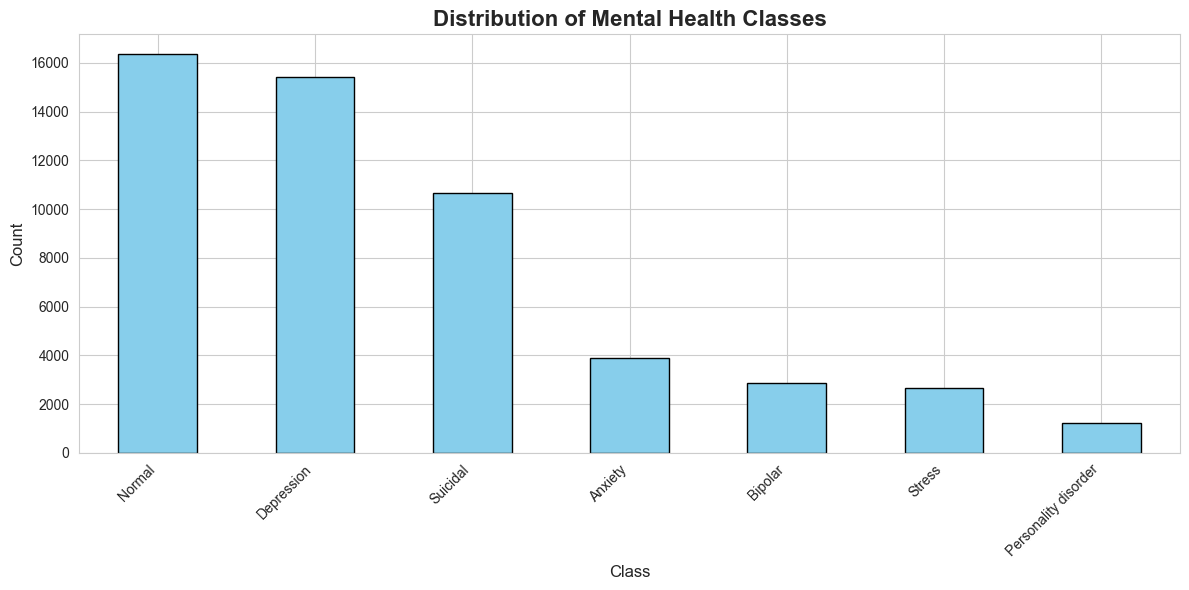


Percentage Distribution:
status
Normal                  30.825934
Depression              29.040590
Suicidal                20.083706
Anxiety                  7.329902
Bipolar                  5.423901
Stress                   5.031767
Personality disorder     2.264201
Name: proportion, dtype: float64


In [6]:
# Class distribution
print("Class Distribution:")
print(df['status'].value_counts())
print("\n" + "="*50)

# Visualize class distribution
plt.figure(figsize=(12, 6))
df['status'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Mental Health Classes', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Percentage distribution
print("\nPercentage Distribution:")
print(df['status'].value_counts(normalize=True) * 100)

In [7]:
# Check missing values in detail
print(f"Missing statements: {df['statement'].isnull().sum()}")
print(f"Examples of rows with missing statements:")
print(df[df['statement'].isnull()].head())

# Drop rows with missing statements
df_clean = df.dropna(subset=['statement'])

# Drop the index column
df_clean = df_clean.drop('Unnamed: 0', axis=1)

print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Missing statements: 362
Examples of rows with missing statements:
      Unnamed: 0 statement   status
293          293       NaN  Anxiety
572          572       NaN  Anxiety
595          595       NaN  Anxiety
1539        1539       NaN   Normal
2448        2448       NaN   Normal

Cleaned dataset shape: (52681, 2)
Rows removed: 362


Text Length Statistics:
        text_length    word_count
count  52681.000000  52681.000000
mean     578.713863    113.158729
std      846.269078    163.735305
min        2.000000      1.000000
25%       80.000000     15.000000
50%      317.000000     62.000000
75%      752.000000    148.000000
max    32759.000000   6300.000000


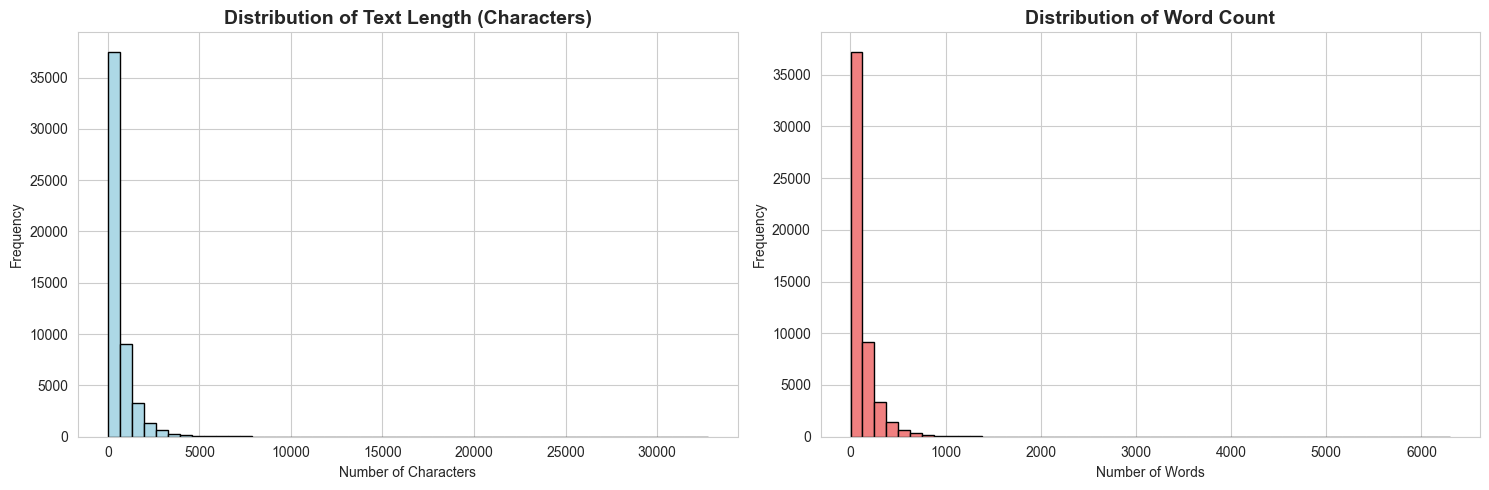

In [8]:
# Add text length column
df_clean['text_length'] = df_clean['statement'].apply(len)
df_clean['word_count'] = df_clean['statement'].apply(lambda x: len(str(x).split()))

# Statistics
print("Text Length Statistics:")
print(df_clean[['text_length', 'word_count']].describe())

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character length
axes[0].hist(df_clean['text_length'], bins=50, color='lightblue', edgecolor='black')
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Word count
axes[1].hist(df_clean['word_count'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Word Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

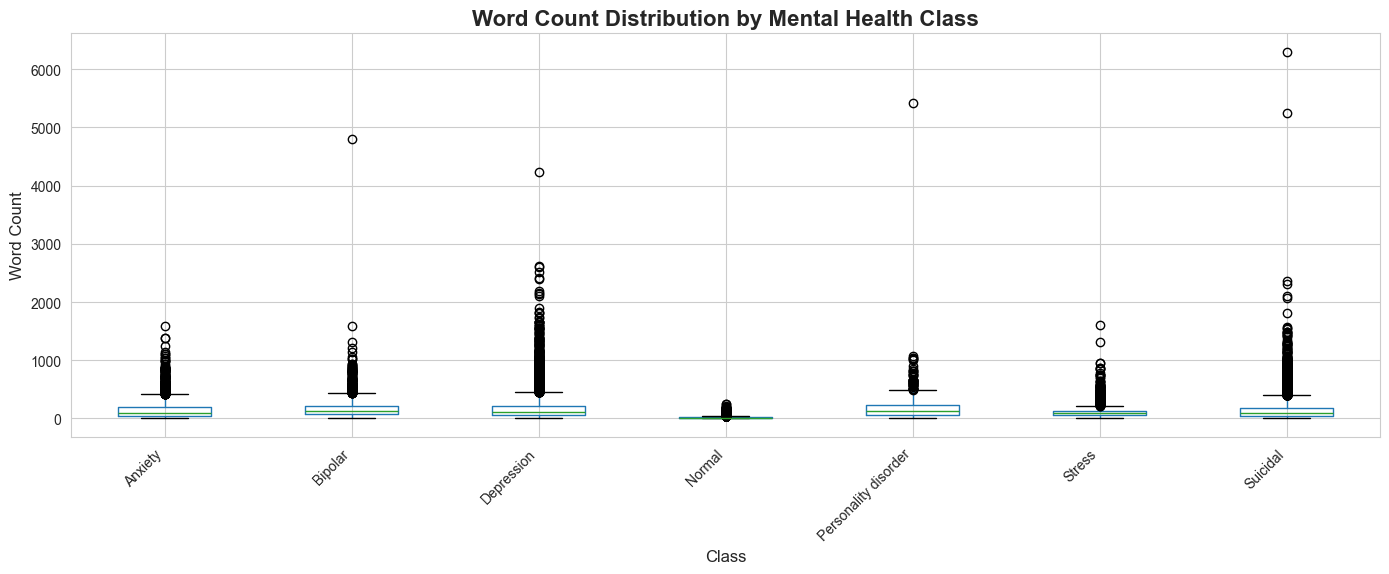


Average Word Count by Class:
status
Personality disorder    179.346332
Bipolar                 176.200216
Depression              168.021488
Suicidal                146.440293
Anxiety                 143.837022
Stress                  114.585234
Normal                   17.246283
Name: word_count, dtype: float64


In [9]:
# Text length by class
plt.figure(figsize=(14, 6))
df_clean.boxplot(column='word_count', by='status', figsize=(14, 6))
plt.title('Word Count Distribution by Class', fontsize=16, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Class', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average word count per class
print("\nAverage Word Count by Class:")
print(df_clean.groupby('status')['word_count'].mean().sort_values(ascending=False))

In [10]:
# Show examples from each class
print("Sample Statements from Each Class:\n")
for class_name in df_clean['status'].unique():
    print(f"\n{'='*60}")
    print(f"Class: {class_name}")
    print('='*60)
    samples = df_clean[df_clean['status'] == class_name]['statement'].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"{i}. {text[:150]}...")  # Show first 150 characters

Sample Statements from Each Class:


Class: Anxiety
1. Is this health anxiety? 1) checking temperature 10 times a day
2) checking blood pressure everyday
3) checking weight 10 times a day

Thinking I might...
2. Is there any way to sleep better? I can't sleep most of the nights, meds didn't help....
3. Lamictal ? Anyone with good reviews about lamictal?...

Class: Normal
1. spring is finally here cherry blossom galore such a shame they are so temporary...
2. is so jeles argh sy pn mau jln sm kau jg sadddddddddddddish...
3. CUET life fucked up...

Class: Depression
1. I try so hard to be happy. For me, for my family for my friends. But I cannot. I am jealous of my friends being happy in their lives but I am also hap...
2. If you do not love someone or cannot promise to love them until you die then do not get into marriages. Its a different kind of pain when you see one ...
3. I have suffered from depression and anxiety for many years now, which has resulted in me losing a lot of friends

In [12]:
# Drop Personality Disorder class
print(f"Original dataset size: {len(df_clean)}")
df_cleaned = df_clean[df_clean['status'] != 'Personality disorder'].copy()
print(f"After dropping Personality disorder: {len(df_cleaned)}")

# Reset index
df_cleaned = df_cleaned.reset_index(drop=True)

# Verify final class distribution
print("\nFinal Class Distribution:")
print(df_cleaned['status'].value_counts())
print("\nPercentage Distribution:")
print(df_cleaned['status'].value_counts(normalize=True) * 100)

# Keep only statement and status columns
df_cleaned = df_cleaned[['statement', 'status']]

print(f"\nFinal dataset shape: {df_cleaned.shape}")

Original dataset size: 52681
After dropping Personality disorder: 51604

Final Class Distribution:
status
Normal        16343
Depression    15404
Suicidal      10652
Anxiety        3841
Bipolar        2777
Stress         2587
Name: count, dtype: int64

Percentage Distribution:
status
Normal        31.670026
Depression    29.850399
Suicidal      20.641811
Anxiety        7.443221
Bipolar        5.381366
Stress         5.013177
Name: proportion, dtype: float64

Final dataset shape: (51604, 2)


In [14]:
import re

def clean_text(text):
    """
    Clean text data for model training
    """
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keep the text)
    text = re.sub(r'#', '', text)
    
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test the function
sample_text = "OMG I'm so anxious!!! 😰 Check this: http://example.com @user #anxiety"
print("Original:", sample_text)
print("Cleaned:", clean_text(sample_text))

Original: OMG I'm so anxious!!! 😰 Check this: http://example.com @user #anxiety
Cleaned: omg im so anxious!!! check this anxiety


In [15]:
# Apply cleaning
print("Cleaning text data...")
df_cleaned['statement_cleaned'] = df_cleaned['statement'].apply(clean_text)

# Check for empty strings after cleaning
empty_count = (df_cleaned['statement_cleaned'] == '').sum()
print(f"\nEmpty strings after cleaning: {empty_count}")

# Remove empty strings if any
if empty_count > 0:
    df_cleaned = df_cleaned[df_cleaned['statement_cleaned'] != ''].copy()
    print(f"Removed {empty_count} empty entries")

# Add text length statistics
df_cleaned['text_length'] = df_cleaned['statement_cleaned'].apply(len)
df_cleaned['word_count'] = df_cleaned['statement_cleaned'].apply(lambda x: len(x.split()))

# Show comparison
print("\nBefore and After Cleaning Examples:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {df_cleaned.iloc[i]['statement'][:100]}...")
    print(f"Cleaned:  {df_cleaned.iloc[i]['statement_cleaned'][:100]}...")

print(f"\nFinal dataset size: {len(df_cleaned)}")

Cleaning text data...

Empty strings after cleaning: 5
Removed 5 empty entries

Before and After Cleaning Examples:

--- Example 1 ---
Original: oh my gosh...
Cleaned:  oh my gosh...

--- Example 2 ---
Original: trouble sleeping, confused mind, restless heart. All out of tune...
Cleaned:  trouble sleeping, confused mind, restless heart. all out of tune...

--- Example 3 ---
Original: All wrong, back off dear, forward doubt. Stay in a restless and restless place...
Cleaned:  all wrong, back off dear, forward doubt. stay in a restless and restless place...

Final dataset size: 51599


In [16]:
# Save to processed folder
output_path = '../data/processed/cleaned_data.csv'
df_cleaned[['statement_cleaned', 'status']].to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"Columns: {df_cleaned[['statement_cleaned', 'status']].columns.tolist()}")
print(f"Shape: {df_cleaned[['statement_cleaned', 'status']].shape}")

Cleaned dataset saved to: ../data/processed/cleaned_data.csv
Columns: ['statement_cleaned', 'status']
Shape: (51599, 2)


In [17]:
from sklearn.model_selection import train_test_split

# Prepare data
X = df_cleaned['statement_cleaned'].values
y = df_cleaned['status'].values

print(f"Total samples: {len(X)}")
print(f"Classes: {df_cleaned['status'].unique()}")

# First split: 70% train, 30% temp (for val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# Second split: Split temp into 50% val, 50% test (15% each of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
print("\nClass distribution in each split:")
print("\nTrain:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nVal:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index())
print("\nTest:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Total samples: 51599
Classes: ['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar']

Split sizes:
Train: 36119 (70.0%)
Val:   7740 (15.0%)
Test:  7740 (15.0%)

Class distribution in each split:

Train:
Anxiety       0.074448
Bipolar       0.053822
Depression    0.298541
Normal        0.316648
Stress        0.050140
Suicidal      0.206401
Name: proportion, dtype: float64

Val:
Anxiety       0.074419
Bipolar       0.053747
Depression    0.298579
Normal        0.316667
Stress        0.050129
Suicidal      0.206460
Name: proportion, dtype: float64

Test:
Anxiety       0.074419
Bipolar       0.053876
Depression    0.298450
Normal        0.316667
Stress        0.050129
Suicidal      0.206460
Name: proportion, dtype: float64


In [20]:
# Create DataFrames for each split
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
val_df = pd.DataFrame({'text': X_val, 'label': y_val})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

# Save splits
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

# Save reference data for drift detection (use train set as reference)
reference_df = train_df.sample(n=min(5000, len(train_df)), random_state=42)
reference_df.to_csv('../data/processed/reference_data.csv', index=False)

print("All splits saved:")
print(f"  - train.csv: {len(train_df)} samples")
print(f"  - val.csv: {len(val_df)} samples")
print(f"  - test.csv: {len(test_df)} samples")
print(f"  - reference_data.csv: {len(reference_df)} samples (for drift detection)")

All splits saved:
  - train.csv: 36119 samples
  - val.csv: 7740 samples
  - test.csv: 7740 samples
  - reference_data.csv: 5000 samples (for drift detection)


In [21]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
classes = df_cleaned['status'].unique()
class_weights = compute_class_weight(
    'balanced',
    classes=classes,
    y=df_cleaned['status']
)

# Create weight dictionary
class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights (for handling imbalance):")
for class_name, weight in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True):
    count = (df_cleaned['status'] == class_name).sum()
    percentage = count / len(df_cleaned) * 100
    print(f"{class_name:20s}: {weight:.3f} (count: {count:5d}, {percentage:5.2f}%)")

# Save class weights to a file
import json
with open('../configs/class_weights.json', 'w') as f:
    json.dump(class_weight_dict, f, indent=2)
print("\nClass weights saved to configs/class_weights.json")

Class Weights (for handling imbalance):
Stress              : 3.324 (count:  2587,  5.01%)
Bipolar             : 3.097 (count:  2777,  5.38%)
Anxiety             : 2.239 (count:  3841,  7.44%)
Suicidal            : 0.807 (count: 10651, 20.64%)
Depression          : 0.558 (count: 15404, 29.85%)
Normal              : 0.526 (count: 16339, 31.67%)

Class weights saved to configs/class_weights.json


In [22]:
# Summary of preprocessing
print("="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"\nOriginal dataset: 53,043 samples")
print(f"After removing missing: 52,681 samples")
print(f"After dropping Personality disorder: {len(df_cleaned)} samples")
print(f"\nFinal classes: {len(df_cleaned['status'].unique())}")
print(f"Final columns: {['text', 'label']}")

print("\nText Statistics (cleaned):")
print(df_cleaned['text_length'].describe())

print("\nFiles created:")
print("  ✅ data/processed/cleaned_data.csv")
print("  ✅ data/processed/train.csv")
print("  ✅ data/processed/val.csv")
print("  ✅ data/processed/test.csv")
print("  ✅ data/processed/reference_data.csv (for drift detection)")
print("  ✅ configs/class_weights.json")

print("\n" + "="*60)
print("✅ PREPROCESSING COMPLETE!")
print("="*60)

PREPROCESSING SUMMARY

Original dataset: 53,043 samples
After removing missing: 52,681 samples
After dropping Personality disorder: 51599 samples

Final classes: 6
Final columns: ['text', 'label']

Text Statistics (cleaned):
count    51599.000000
mean       565.731855
std        831.949863
min          2.000000
25%         75.000000
50%        307.000000
75%        734.000000
max      32759.000000
Name: text_length, dtype: float64

Files created:
  ✅ data/processed/cleaned_data.csv
  ✅ data/processed/train.csv
  ✅ data/processed/val.csv
  ✅ data/processed/test.csv
  ✅ data/processed/reference_data.csv (for drift detection)
  ✅ configs/class_weights.json

✅ PREPROCESSING COMPLETE!
